# EDA - Memorias RAM PcComponentes

## Instrucciones para ejecutar
1. Ejecuta las celdas **en orden** (de arriba hacia abajo).
2. La celda de carga configura el path automáticamente usando `config/settings.py`.
3. Verás impresiones de las rutas y los resultados (prints + gráficos) al ejecutar cada celda de código.
4. Las explicaciones están en las celdas Markdown que siguen a cada análisis.

**Dependencias** (si hace falta):
```python
# !pip install pandas matplotlib seaborn numpy
```

## Objetivo
Explorar los datos brutos extraídos de PcComponentes para memorias RAM (~1646 productos).

Este análisis nos ayudará a:
- Entender la distribución del catálogo actual
- Identificar campos con problemas de extracción (ej. voltaje)
- Descubrir patrones en precio, especificaciones y opiniones
- Definir features útiles de cara al clustering futuro (Fase 02)
- Detectar oportunidades de mejora en los scrapers

**Datos utilizados:** `data/brutos/ram/listado_ram.json` + `detalle_ram.json` (rutas desde config/settings.py)


## 1. Carga de datos y preparación


In [1]:
# ============================================================
# CELDA 1: CARGA DE DATOS Y PREPARACIÓN DEL ENTORNO
# ============================================================
# - Configura el path del proyecto de forma robusta (ejecutable desde notebooks/ o raíz)
# - Carga las rutas centralizadas desde config/settings.py
# - Lee los JSON brutos generados por los scrapers (listado + detalle)
# - Crea DataFrames base para el análisis posterior
# ============================================================

import json
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo global para los gráficos del notebook
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
%matplotlib inline


# ------------------------------------------------------------
# Detección robusta de la raíz del proyecto
# Busca hacia arriba en la jerarquía de carpetas hasta encontrar config/settings.py
# ------------------------------------------------------------
def get_project_root():
    """Devuelve la ruta raíz del proyecto buscando config/settings.py hacia arriba."""
    current = Path.cwd().resolve()
    for parent in [current] + list(current.parents):
        if (parent / "config" / "settings.py").exists():
            return parent
    # Fallback razonable si se ejecuta desde notebooks/
    return current.parent if current.name == "notebooks" else current


# Añadir raíz al sys.path para poder importar config.settings
project_root = get_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Rutas oficiales de los archivos de datos RAM (centralizadas en settings)
from config.settings import RAM_LISTADO_JSON, RAM_DETALLE_JSON

listado_path = RAM_LISTADO_JSON
detalle_path = RAM_DETALLE_JSON

print("Cargando desde:")
print("  -", listado_path)
print("  -", detalle_path)

# Carga de JSONs generados por scraper (listado resumido + detalle enriquecido)
with open(listado_path, encoding="utf-8") as f:
    listado = json.load(f)

with open(detalle_path, encoding="utf-8") as f:
    detalle = json.load(f)

# DataFrames principales que usaremos en todo el EDA
productos_listado = pd.DataFrame(listado["productos"])
productos_detalle = pd.DataFrame(detalle["productos"])

print("\nListado productos:", len(productos_listado))
print("Detalle productos:", len(productos_detalle))
print("Errores:", len(detalle.get("errores", [])))


Cargando desde:
  - C:\Visual Code\PC_COMPONENTES\pccomponentes-ml-analysis\data\brutos\ram\listado_ram.json
  - C:\Visual Code\PC_COMPONENTES\pccomponentes-ml-analysis\data\brutos\ram\detalle_ram.json

Listado productos: 1646
Detalle productos: 1574
Errores: 0


## 2. Resumen General del Dataset

- **Productos en listado**: 1646
- **Productos con detalle completo**: 1574
- **Total reseñas recolectadas**: ~5.876 (aprox 3.7 por producto)

Nota: Hay una ligera diferencia entre listado y detalle. Algunos productos no devolvieron ficha completa en el momento del scraping.


## 3. Análisis de Precios


=== Estadísticas de precio ===
count    1574.000000
mean      560.544701
std       629.368398
min         1.210000
25%       176.927500
50%       389.500000
75%       701.082500
max      7681.060000
Name: precio, dtype: float64

Productos con precio < 50€: 64
Productos con precio > 2000€: 46


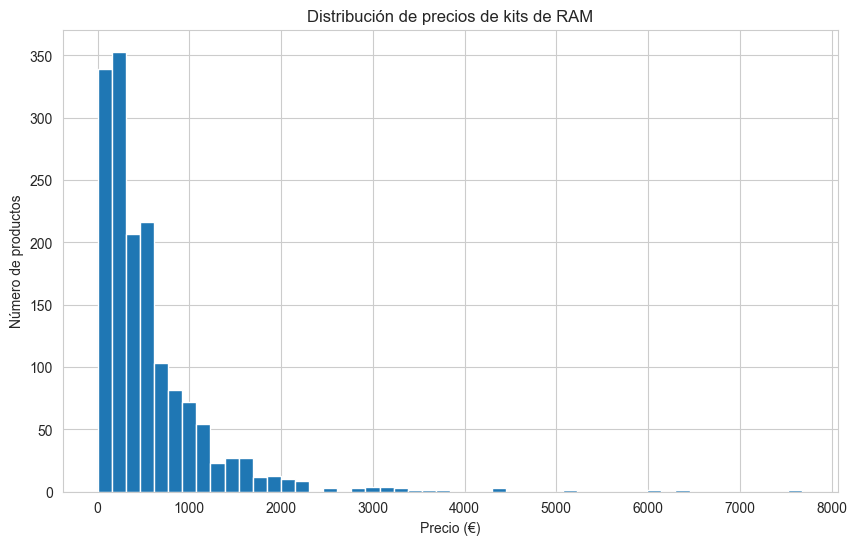

In [2]:
# ============================================================
# CELDA 2: ANÁLISIS DE PRECIOS
# ============================================================
# - Unimos el detalle (precio real de ficha) con datos del listado (precio, valoración, nº opiniones)
# - Estadísticas descriptivas + histograma de distribución de precios
# ============================================================

# Merge left para conservar todos los productos con detalle y enriquecer con campos del listado
df = productos_detalle.merge(
    productos_listado[["id", "precio_listado", "valoracion_listado", "num_opiniones_listado"]], 
    on="id", how="left"
)

# Estadísticas básicas de precio (media, std, min, quartiles, max)
print("=== Estadísticas de precio ===")
print(df["precio"].describe())

# Detección rápida de outliers de precio
print("\nProductos con precio < 50€:", (df["precio"] < 50).sum())
print("Productos con precio > 2000€:", (df["precio"] > 2000).sum())

# Histograma simple para visualizar la distribución
df["precio"].hist(bins=50)
plt.title("Distribución de precios de kits de RAM")
plt.xlabel("Precio (€)")
plt.ylabel("Número de productos")
plt.show()


**Observaciones precios:**
- Rango muy amplio (desde ~1€ hasta kits de gama alta >7000€).
- Mediana alrededor de 390€ → muchos kits de 32GB DDR5 de gama media-alta.
- Outliers caros suelen ser configuraciones de 128GB+ o muy alta frecuencia.


### Visualización complementaria de precios sin outliers extremos

La siguiente gráfica muestra la distribución de precios filtrando visualmente los valores por encima del percentil 99.  
El objetivo es ver mejor dónde se concentra la mayoría de productos sin modificar todavía los datos brutos.

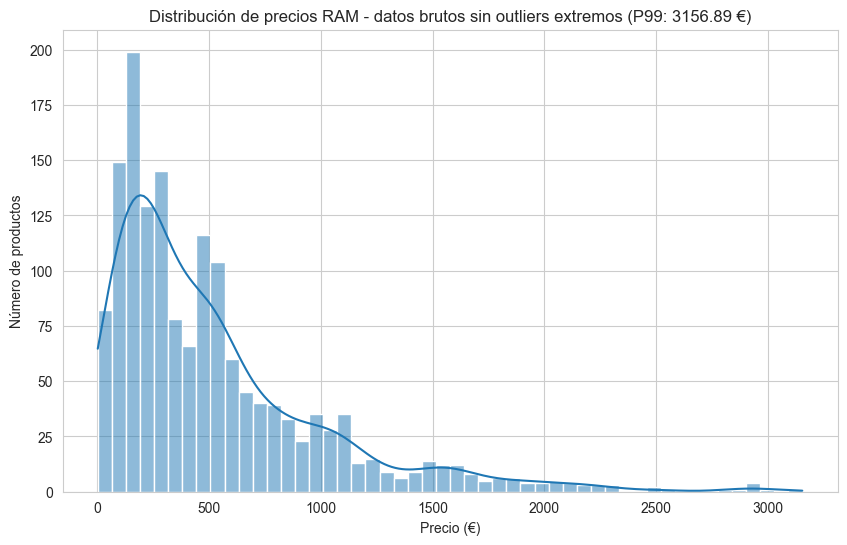

In [4]:
# Distribución de precios brutos sin outliers extremos
# Filtramos visualmente hasta el percentil 99 para que los precios muy altos no aplasten la gráfica.

precio_p99 = df["precio"].quantile(0.99)
df_precio_filtrado = df[df["precio"] <= precio_p99]

plt.figure(figsize=(10, 6))
sns.histplot(df_precio_filtrado["precio"], bins=50, kde=True)

plt.title(f"Distribución de precios RAM - datos brutos sin outliers extremos (P99: {precio_p99:.2f} €)")
plt.xlabel("Precio (€)")
plt.ylabel("Número de productos")

plt.show()

**Observaciones precios:**

- Se filtran visualmente los precios por encima del percentil 99 para evitar que los valores extremos deformen la gráfica.
- La mayor parte de los kits de RAM se concentra en rangos medios, por debajo del umbral mostrado.
- La mediana (~390€) representa mejor el producto típico que la media, ya que existen precios muy altos en los datos brutos.
- Los outliers caros pueden ser kits de gran capacidad, configuraciones profesionales o posibles errores de extracción.
- Esta gráfica será útil para comparar el antes/después tras la limpieza.

### Visualización complementaria de outliers de precio

El siguiente boxplot permite identificar visualmente la dispersión de precios y los posibles valores extremos.  
Esta visualización ayuda a decidir qué casos revisar durante la fase de limpieza.

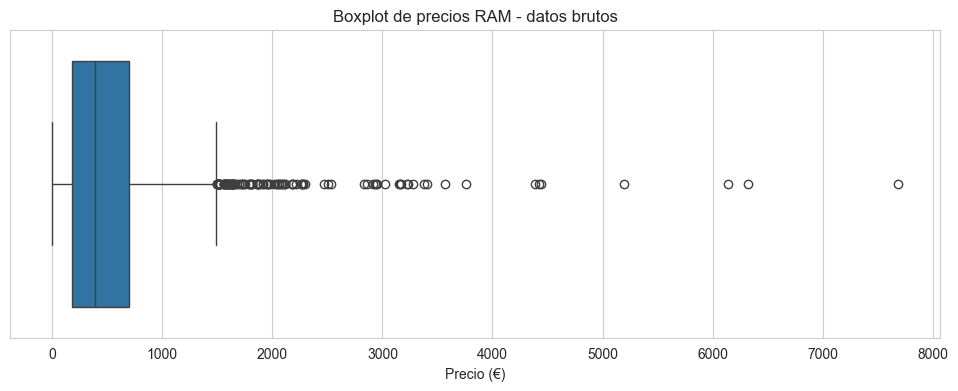

In [5]:
# Boxplot de precios brutos
# Sirve para visualizar la dispersión y detectar valores extremos.

plt.figure(figsize=(12, 4))
sns.boxplot(x=df["precio"])

plt.title("Boxplot de precios RAM - datos brutos")
plt.xlabel("Precio (€)")

plt.show()

In [6]:
# Detección de outliers de precio con la regla IQR

q1 = df["precio"].quantile(0.25)
q3 = df["precio"].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers_precio = df[
    (df["precio"] < limite_inferior) |
    (df["precio"] > limite_superior)
]

print("Q1:", round(q1, 2))
print("Q3:", round(q3, 2))
print("IQR:", round(iqr, 2))
print("Límite inferior:", round(limite_inferior, 2))
print("Límite superior:", round(limite_superior, 2))
print("Número de outliers de precio:", len(outliers_precio))

outliers_precio[["id", "nombre", "precio"]].sort_values("precio", ascending=False).head(10)

Q1: 176.93
Q3: 701.08
IQR: 524.16
Límite inferior: -609.3
Límite superior: 1487.32
Número de outliers de precio: 111


,id,nombre,precio
1287,ram_1288,Memoria RAM G.Skill Trident Z5 Neo RGB F5-6000...,7681.06
1359,ram_1360,Memoria RAM HPE 64GB DDR5 4800MHz P43331-B21,6318.33
1361,ram_1362,Memoria RAM HPE P50312-B21 64GB 1x64GB DDR5 48...,6134.91
1240,ram_1241,Memoria RAM G.Skill Ripjaws M5 RGB 64GB 2x32GB...,5191.57
1452,ram_1453,Memoria RAM Lenovo 4X77A81441 64GB 1x64GB DDR5...,4443.84
1212,ram_1213,Memoria RAM G.Skill Flare X5 F5-5200J4040A32GX...,4424.89
647,ram_0648,Memoria RAM Kingston KSM64R52BD4-64HA 64GB 1x6...,4389.15
1368,ram_1369,Memoria RAM HPE SmartMemory 64GB 1x64GB DDR4 2...,3761.99
1549,ram_1550,Memoria RAM Synology 32GB DDR4 2400MHz ECC D4E...,3569.42
972,ram_0973,G.Skill Ripjaws V DDR4 3200Mhz PC4-25600 64GB ...,3402.26


**Observaciones boxplot de precios:**

- La regla IQR marca como outliers los productos con precio superior a ~1487€.
- Se detectan 111 productos como outliers de precio en los datos brutos.
- El límite inferior calculado es negativo, por lo que no tiene interpretación práctica en precios.
- Los outliers superiores pueden corresponder a kits de gran capacidad, productos profesionales o posibles errores de extracción.
- Estos casos deberán revisarse durante la limpieza para decidir si se conservan, se corrigen o se excluyen de ciertos análisis.

## 4. Especificaciones Técnicas


In [7]:
# ============================================================
# CELDA 3: ESPECIFICACIONES TÉCNICAS (parte 1)
# ============================================================
# - Normalizamos el campo JSON "especificaciones" a columnas planas
# - Analizamos tipo de memoria (DDR4 vs DDR5), capacidad y primeros problemas de parseo
# ============================================================

# Desanidar el diccionario de especificaciones técnicas extraído por el scraper
especs = pd.json_normalize(df["especificaciones"])

# --- Tipo de memoria ---
print("=== Tipo de memoria ===")
print(especs["tipo_memoria"].value_counts(dropna=False))

# --- Capacidad total del kit (en GB) ---
# Usamos to_numeric con errors='coerce' para convertir fallos a NaN
capacidad = pd.to_numeric(especs["capacidad_gb"], errors="coerce")
print("\n=== Capacidad total (GB) ===")
print(capacidad.describe())
print("Valores sospechosamente altos (>1000):", (capacidad > 1000).sum())


=== Tipo de memoria ===
tipo_memoria
DDR5    824
DDR4    580
NaN      87
DDR3     83
Name: count, dtype: int64

=== Capacidad total (GB) ===
count    1.520000e+03
mean     2.868669e+05
std      1.108318e+07
min      1.000000e+00
25%      1.600000e+01
50%      3.200000e+01
75%      3.200000e+01
max      4.321025e+08
Name: capacidad_gb, dtype: float64
Valores sospechosamente altos (>1000): 38


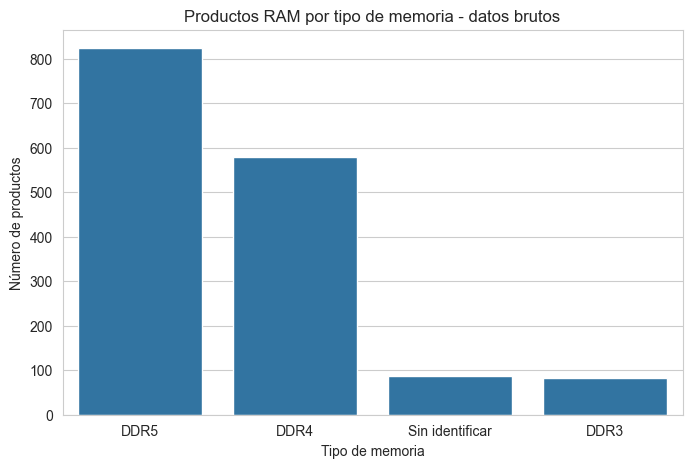

In [8]:
# Distribución de productos por tipo de memoria

tipo_memoria_counts = (
    especs["tipo_memoria"]
    .fillna("Sin identificar")
    .value_counts()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=tipo_memoria_counts.index,
    y=tipo_memoria_counts.values
)

plt.title("Productos RAM por tipo de memoria - datos brutos")
plt.xlabel("Tipo de memoria")
plt.ylabel("Número de productos")

plt.show()

**Lectura de la gráfica:**

- La visualización confirma el predominio de DDR5 que ya aparecía en el conteo.
- DDR4 mantiene una presencia relevante, por lo que conviene conservarlo como segmento propio en análisis posteriores.
- La categoría "Sin identificar" permite ver cuántos productos no fueron clasificados por el parser.
- Esta gráfica se puede repetir después de la limpieza para comprobar si se reduce el número de productos sin tipo identificado.

### Visualización complementaria de capacidad RAM

La siguiente gráfica muestra la distribución de capacidad total del kit, filtrando visualmente valores superiores a 256 GB.  
El objetivo es observar las capacidades habituales sin que los errores extremos de parseo deformen la gráfica.

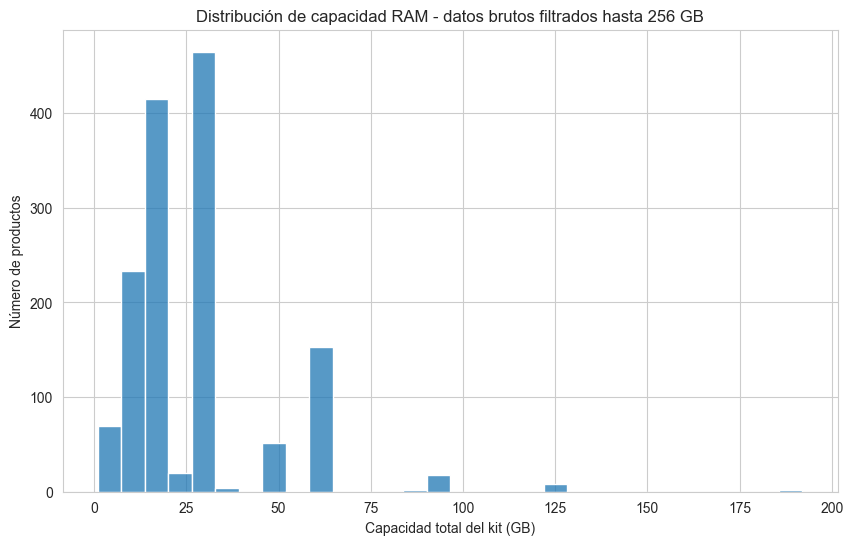

In [10]:
# Distribución de capacidad total en GB
# Filtramos valores extremos para visualizar mejor los kits habituales.

capacidad = pd.to_numeric(especs["capacidad_gb"], errors="coerce")

capacidad_filtrada = capacidad[
    (capacidad.notna()) &
    (capacidad > 0) &
    (capacidad <= 256)
]

plt.figure(figsize=(10, 6))
sns.histplot(capacidad_filtrada, bins=30)

plt.title("Distribución de capacidad RAM - datos brutos filtrados hasta 256 GB")
plt.xlabel("Capacidad total del kit (GB)")
plt.ylabel("Número de productos")

plt.show()

**Lectura de la gráfica:**

- Se filtran valores superiores a 256 GB para evitar que errores extremos de parseo deformen la visualización.
- La mayor concentración de productos aparece en capacidades habituales como 16 GB y 32 GB.
- El filtrado es solo visual: los datos brutos originales siguen sin modificarse.
- Los valores superiores a 1000 GB detectados previamente deberán revisarse en la fase de limpieza.

In [11]:
# ============================================================
# CELDA 4: ESPECIFICACIONES TÉCNICAS (parte 2 - frecuencia y latencia)
# ============================================================
# - Frecuencia en MHz (importante para rendimiento)
# - Latencia CL (Column Latency) - valores más comunes y nulos
# ============================================================

# --- Frecuencia ---
frec = pd.to_numeric(especs["frecuencia_mhz"], errors="coerce")
print("=== Frecuencia (MHz) ===")
print(frec.describe())

# --- Latencia CL ---
print("\n=== Latencia CL más comunes ===")
print(especs["latencia_cl"].value_counts(dropna=False).head(10))


=== Frecuencia (MHz) ===
count    1379.000000
mean     4569.770848
std      1609.283644
min       533.000000
25%      3200.000000
50%      5200.000000
75%      6000.000000
max      8800.000000
Name: frecuencia_mhz, dtype: float64

=== Latencia CL más comunes ===
latencia_cl
NaN     279
40.0    195
16.0    158
22.0    136
36.0    134
46.0     95
32.0     89
30.0     79
19.0     76
11.0     65
Name: count, dtype: int64


**Hallazgos importantes en specs:**
- DDR5 ya es mayoritario (824 vs 580 DDR4).
- Muchos valores de capacidad parecen mal parseados (números enormes — problema de extracción).
- Frecuencia media ~4570 MHz, con pico fuerte en 5200-6000 MHz (típico DDR5 gaming).
- Latencia CL tiene bastantes nulos. Los valores más comunes son 40, 16, 22, 36.


### Visualización complementaria de frecuencia RAM

La siguiente gráfica amplía visualmente los hallazgos sobre frecuencia, mostrando la distribución de MHz en los datos brutos.  
No se modifica el dataset; solo se representa de forma más clara para detectar patrones y valores poco habituales.

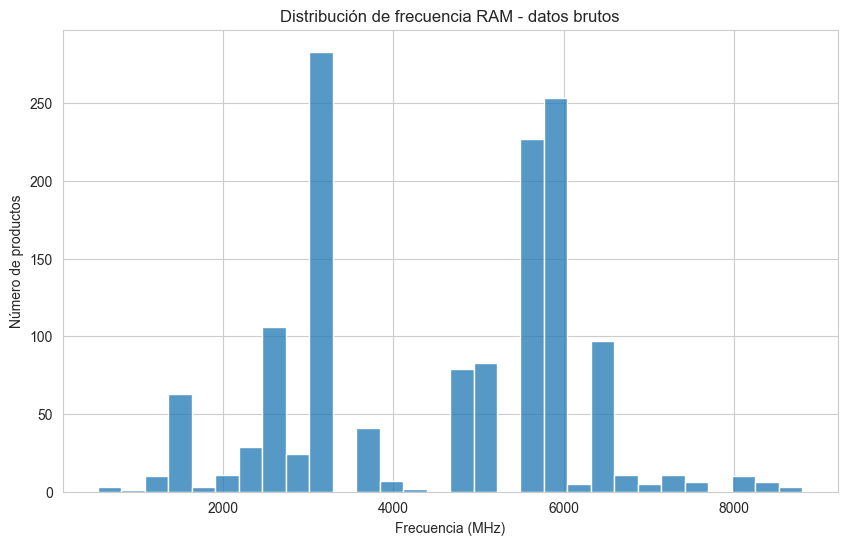

In [12]:
# Distribución de frecuencia RAM en MHz

frec = pd.to_numeric(especs["frecuencia_mhz"], errors="coerce")
frec_filtrada = frec[
    (frec.notna()) &
    (frec > 0)
]

plt.figure(figsize=(10, 6))
sns.histplot(frec_filtrada, bins=30)

plt.title("Distribución de frecuencia RAM - datos brutos")
plt.xlabel("Frecuencia (MHz)")
plt.ylabel("Número de productos")

plt.show()

**Lectura de la gráfica:**

- La distribución muestra varios grupos claros de frecuencia, coherentes con la mezcla de memorias DDR3, DDR4 y DDR5.
- Se observa un pico importante alrededor de 3200 MHz, habitual en memorias DDR4.
- También se aprecia una concentración fuerte entre 5200 y 6000 MHz, típica de memorias DDR5.
- Hay algunos valores de frecuencia más altos, por encima de 7000 MHz, que podrían corresponder a kits de alto rendimiento.
- Esta gráfica servirá como referencia para comprobar si la limpieza posterior mantiene los valores válidos y ayuda a detectar valores poco habituales.

### Visualización complementaria de latencia CL

La siguiente gráfica muestra las latencias CL más frecuentes en los datos brutos.  
También nos ayuda a ver cuántos productos tienen este campo sin identificar o con valores poco habituales.

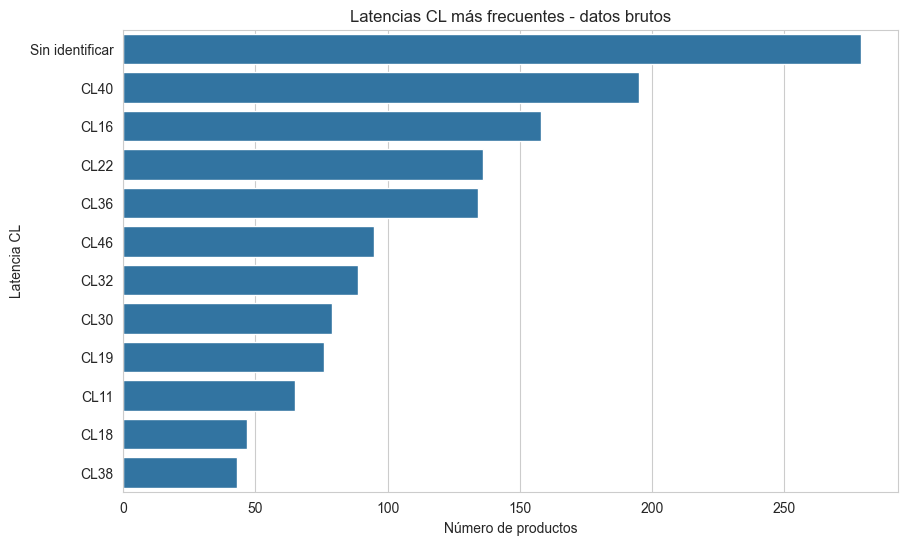

In [13]:
# Latencias CL más frecuentes

latencia = pd.to_numeric(especs["latencia_cl"], errors="coerce")

latencia_counts = (
    latencia
    .fillna(-1)
    .value_counts()
    .sort_values(ascending=False)
    .head(12)
)

latencia_labels = [
    "Sin identificar" if valor == -1 else f"CL{int(valor)}"
    for valor in latencia_counts.index
]

plt.figure(figsize=(10, 6))
sns.barplot(
    x=latencia_counts.values,
    y=latencia_labels
)

plt.title("Latencias CL más frecuentes - datos brutos")
plt.xlabel("Número de productos")
plt.ylabel("Latencia CL")

plt.show()

**Lectura de la gráfica:**

- La categoría "Sin identificar" es la más frecuente, lo que confirma que la latencia CL tiene un problema importante de cobertura en los datos brutos.
- Entre los valores identificados destacan CL40, CL16, CL22 y CL36.
- Conviene revisar este campo más adelante, porque la latencia ayuda a comparar mejor unas memorias RAM con otras.

## 5. El problema del Voltaje (campo crítico)


In [14]:
# ============================================================
# CELDA 5: PROBLEMA CRÍTICO - CAMPO VOLTAJE
# ============================================================
# El voltaje es una especificación clave para compatibilidad y estabilidad.
# Aquí detectamos que no se está extrayendo (problema conocido en To_Do_List).
# ============================================================

print("Voltaje nulos:", especs["voltaje"].isna().sum(), "/", len(especs))
print("Valores únicos de voltaje:", especs["voltaje"].unique()[:5])


Voltaje nulos: 1574 / 1574
Valores únicos de voltaje: [None]


**Conclusión clara:** El campo `voltaje` no se está extrayendo en absoluto (100% nulo).  

Esto coincide con el To_Do_List. Es una prioridad de mejora en el parser de `detalle_ram.py` o mediante re-procesado de las fichas HTML guardadas si las tenemos.


## 6. Reseñas y Valoraciones de usuarios


In [15]:
# ============================================================
# CELDA 6: RESEÑAS Y VALORACIONES DE USUARIOS
# ============================================================
# - Aplanamos la lista de reseñas embebidas en cada producto del detalle
# - Añadimos producto_id para poder relacionarlas después
# - Métricas de cobertura de pros/contras y distribución de estrellas
# NOTA: Actualmente son solo una muestra (JSON-LD embebido), no todas las reseñas.
# ============================================================

all_resenas = []
for p in detalle["productos"]:
    resenas_producto = p.get("resenas") or []
    for r in resenas_producto:
        # Creamos una copia para no mutar el JSON original cargado en memoria
        r_copia = dict(r)
        r_copia["producto_id"] = p["id"]
        all_resenas.append(r_copia)

resenas_df = pd.DataFrame(all_resenas)

print(f"Total reseñas recolectadas: {len(resenas_df)}")
print(f"Reseñas por producto (media): {len(resenas_df) / len(detalle['productos']):.1f}")

print("\nDistribución de estrellas en reseñas individuales:")
print(resenas_df["valoracion"].value_counts(dropna=False).sort_index())

print("\n% con pros:", round(resenas_df["pros"].notna().mean()*100, 1))
print("% con contras:", round(resenas_df["contras"].notna().mean()*100, 1))


Total reseñas recolectadas: 5876
Reseñas por producto (media): 3.7

Distribución de estrellas en reseñas individuales:
valoracion
0.5      34
1.0      34
1.5       9
2.0      24
2.5      24
3.0     106
3.5     112
4.0     502
4.5     679
5.0    4352
Name: count, dtype: int64

% con pros: 60.1
% con contras: 52.6


**Observaciones reseñas:**
- Fuerte sesgo positivo: la inmensa mayoría son 5 estrellas (4352 de ~5876).
- Solo ~3.7 reseñas por producto de media (recordemos que son solo una muestra embebida en JSON-LD, no todas las opiniones del producto).
- Pros y contras están presentes en la mayoría de las reseñas recolectadas → material excelente para NLP y extracción de temas.
- El campo `opinion_verificada` parece no haberse extraído (todo nulo en los datos actuales).


### Visualización complementaria de valoraciones en reseñas

La siguiente gráfica muestra la distribución de valoraciones individuales recogidas en las reseñas del JSON bruto.  
Sirve para ver de forma visual si las opiniones están equilibradas o si existe un sesgo hacia valoraciones altas.

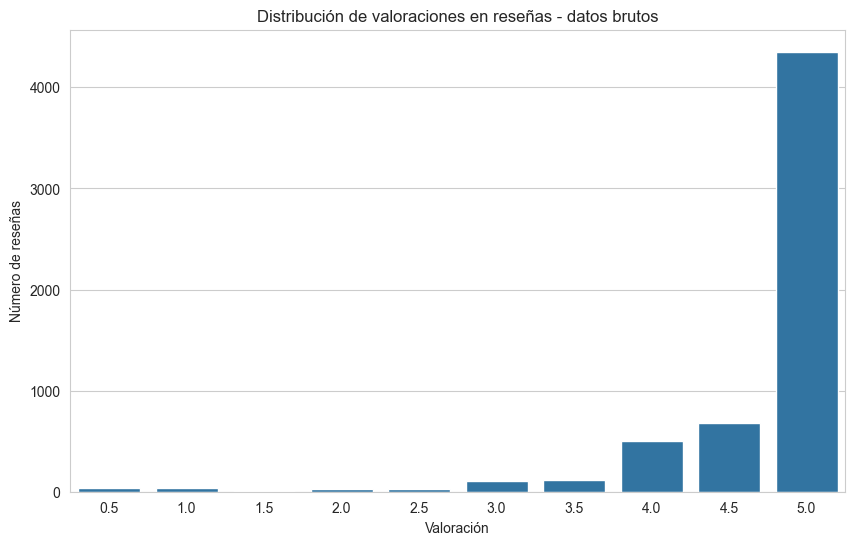

In [ ]:
# Distribución de valoraciones individuales en reseñas

valoraciones_counts = (
    resenas_df["valoracion"]
    .value_counts()
    .sort_index() 
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=valoraciones_counts.index.astype(str),
    y=valoraciones_counts.values
)

plt.title("Distribución de valoraciones en reseñas - datos brutos")
plt.xlabel("Valoración")
plt.ylabel("Número de reseñas")

plt.show()

**Lectura de la gráfica:**

- La distribución de valoraciones está claramente concentrada en puntuaciones altas.
- La valoración de 5 estrellas domina con mucha diferencia sobre el resto.
- Las valoraciones bajas existen, pero representan una parte pequeña del total de reseñas recogidas.
- Este sesgo positivo debe tenerse en cuenta si más adelante usamos las reseñas para análisis de sentimiento o clustering.

### Visualización complementaria de pros y contras

La siguiente gráfica muestra qué porcentaje de reseñas incluye información en los campos `pros` y `contras`.  
Esto ayuda a valorar si esos campos tienen suficiente contenido para analizarlos más adelante.

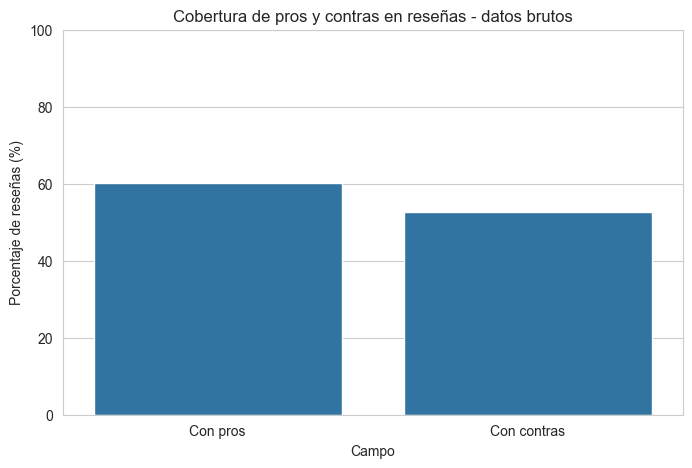

In [17]:
# Cobertura de campos pros y contras en reseñas

cobertura_pros_contras = pd.Series({
    "Con pros": resenas_df["pros"].notna().mean() * 100,
    "Con contras": resenas_df["contras"].notna().mean() * 100
})

plt.figure(figsize=(8, 5))
sns.barplot(
    x=cobertura_pros_contras.index,
    y=cobertura_pros_contras.values
)

plt.title("Cobertura de pros y contras en reseñas - datos brutos")
plt.xlabel("Campo")
plt.ylabel("Porcentaje de reseñas (%)")
plt.ylim(0, 100)

plt.show()


**Lectura de la gráfica:**

- Aproximadamente un 60% de las reseñas incluye información en el campo `pros`.
- Algo más de la mitad de las reseñas incluye información en el campo `contras`.
- Estos campos tienen bastante contenido útil, aunque no están presentes en todas las reseñas.
- Más adelante podrían servir para analizar opiniones positivas y negativas de forma separada.

## 7. Marcas más comunes


In [18]:
# ============================================================
# CELDA 7: EXTRACCIÓN SIMPLE DE MARCA DESDE EL NOMBRE
# ============================================================
# Función heurística para inferir marca a partir del nombre del producto.
# Se usa para análisis rápido de participación de mercado.
# En el futuro se debería normalizar desde el scraper o con un catálogo maestro.
# ============================================================

def extraer_marca(nombre):
    """Extrae la marca conocida más probable del nombre del producto (upper case match)."""
    nombre = str(nombre).upper()
    # Orden intencional: primero las más específicas / frecuentes
    marcas_conocidas = [
        "KINGSTON", "CORSAIR", "G.SKILL", "CRUCIAL", "SAMSUNG", "TEAMGROUP",
        "PATRIOT", "ADATA", "LEXAR", "KLEVV", "FORGEON", "XPG", "GOODRAM", "PNY"
    ]
    for marca in marcas_conocidas:
        if marca in nombre:
            return marca
    return "OTROS / DESCONOCIDA"


# Aplicamos la función y mostramos el conteo de las principales
df["marca"] = df["nombre"].apply(extraer_marca)
print(df["marca"].value_counts().head(12))


marca
OTROS / DESCONOCIDA    354
KINGSTON               303
G.SKILL                302
CORSAIR                246
CRUCIAL                104
PATRIOT                 90
GOODRAM                 65
ADATA                   51
LEXAR                   24
PNY                     16
SAMSUNG                  7
KLEVV                    5
Name: count, dtype: int64


Marcas dominantes: Kingston, G.Skill y Corsair lideran claramente. Hay un volumen importante de "OTROS".


### Visualización complementaria de marcas detectadas

La siguiente gráfica muestra las marcas más frecuentes inferidas a partir del nombre del producto.  
Este análisis es aproximado, porque la marca todavía no viene como un campo limpio del scraper.

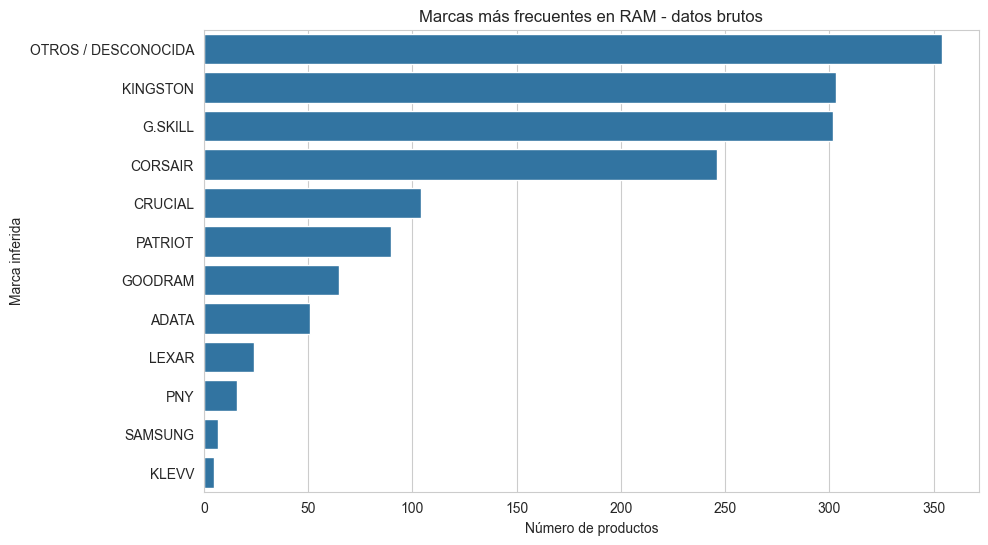

In [19]:
# Marcas más frecuentes detectadas a partir del nombre del producto

marcas_counts = df["marca"].value_counts().head(12)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=marcas_counts.values,
    y=marcas_counts.index
)

plt.title("Marcas más frecuentes en RAM - datos brutos")
plt.xlabel("Número de productos")
plt.ylabel("Marca inferida")

plt.show()

**Lectura de la gráfica:**

- La categoría `OTROS / DESCONOCIDA` es la más frecuente, lo que indica que la detección de marca todavía es limitada.
- Entre las marcas reconocidas destacan Kingston, G.Skill y Corsair.
- La marca no viene como un campo limpio en el JSON bruto, por eso se obtiene buscando nombres de marcas dentro del nombre del producto.
- En la fase de limpieza convendrá mejorar esta detección para reducir la categoría `OTROS / DESCONOCIDA`.

## 8. Calidad de los datos y campos problemáticos


### Campos con problemas detectados:
- **voltaje**: 100% nulo → prioridad alta de mejora en scraping
- **latencia_cl**: bastantes nulos (~18%)
- **capacidad_gb**: algunos valores absurdamente altos (problema de parseo en el scraper)
- **valoracion_media / num_opiniones**: en muchos casos aparecen como 0 (posible bug en la extracción del bloque de opiniones)
- **opinion_verificada**: no se está capturando

### Diferencia listado vs detalle
Hay unos 72 productos que están en el listado pero no tienen detalle completo. Merece la pena investigar (posibles bloqueos puntuales o productos eliminados entre runs).


### Visualización complementaria de valores nulos

La siguiente gráfica muestra el porcentaje de valores nulos en algunas columnas importantes de especificaciones y opiniones.  
Sirve para identificar rápidamente qué campos tienen peor cobertura en los datos brutos.

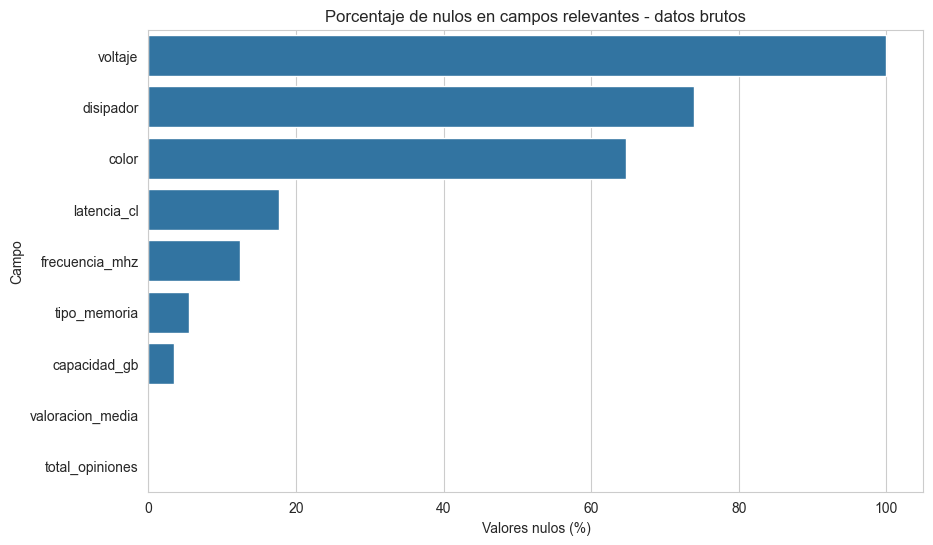

In [20]:
# Porcentaje de valores nulos en campos importantes

campos_calidad = pd.DataFrame({
    "tipo_memoria": especs["tipo_memoria"],
    "capacidad_gb": especs["capacidad_gb"],
    "frecuencia_mhz": especs["frecuencia_mhz"],
    "latencia_cl": especs["latencia_cl"],
    "voltaje": especs["voltaje"],
    "color": especs["color"],
    "disipador": especs["disipador"],
    "valoracion_media": df["opiniones"].apply(lambda x: x.get("valoracion_media") if isinstance(x, dict) else None),
    "total_opiniones": df["opiniones"].apply(lambda x: x.get("total_opiniones") if isinstance(x, dict) else None),
})

nulos_porcentaje = (
    campos_calidad
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=nulos_porcentaje.values,
    y=nulos_porcentaje.index
)

plt.title("Porcentaje de nulos en campos relevantes - datos brutos")
plt.xlabel("Valores nulos (%)")
plt.ylabel("Campo")

plt.show()

**Lectura de la gráfica:**

- La gráfica resume visualmente la cobertura de varios campos relevantes del JSON bruto.
- Se confirma que `voltaje` no tiene datos informados y que `disipador` y `color` tienen muchos valores vacíos.
- Los campos de opiniones incluidos en esta comparación aparecen prácticamente completos.

## 9. Conclusiones y Recomendaciones


### Lo bueno
- Buen volumen de datos (1646 productos + casi 6k reseñas).
- Cobertura decente de DDR5 (ya representa la mayoría del catálogo actual).
- Pros/contras disponibles en la mayoría de reseñas → material excelente para análisis de sentimiento y extracción de temas (Fase 02).
- El sistema de scraping parece robusto (0 errores reportados en el JSON).

### Áreas de mejora urgentes (antes de modelado / DB)
1. **Reparar extracción de voltaje** (crítico para especificaciones técnicas reales).
2. **Mejorar parsing de capacidad_gb y latencia_cl** (hay basura numérica en los datos).
3. **Revisar extracción de valoraciones/resumen de opiniones** (muchos ceros sospechosos).
4. **Evaluar re-run selectivo** de productos con datos incompletos o enriquecer con sección completa de opiniones (actualmente solo muestra embebida).
5. **Normalizar marcas y modelos** para futuro clustering.

### Features interesantes para clustering (Fase 02)
- Capacidad total + num_módulos + capacidad_por_módulo
- Frecuencia + Latencia (CL)
- Tipo de memoria (DDR4 / DDR5)
- Precio (quizá log o por GB)
- Score de sentimiento de reseñas (una vez tengamos NLP)
- Presencia de disipador / RGB (campo 'diseno')
- Marca (one-hot o embedding)

### Próximos pasos sugeridos (sin tocar DB todavía)
- Crear scripts de post-procesado que limpien/enriquezcan los JSONs actuales.
- Completar la documentación y scrapers de Tarjetas Gráficas.
- Empezar a prototipar funciones de normalización de especificaciones en `pipeline/`.
- Seguir con EDA más profunda (correlaciones precio-specs, análisis de texto de pros/contras).
